In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt 
%matplotlib inline
# plot in output cell, not in separate windows.

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

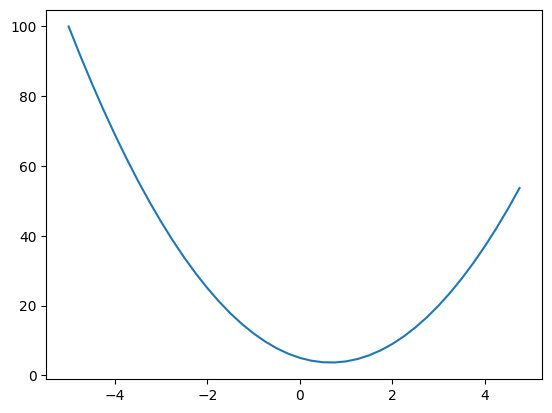

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
# derivative at x = 3.0
h = 1e-5
y1 = f(3.0)
y2 = f(3.0 + h)

df_dx = (y2 - y1) / h
print(df_dx)

14.00003000000538


analytical derivative of $f(x) = 3x^2 - 4x + 5$ is $f'(x) = 6x - 4$ at $x = 3.0$ is $f'(3.0) = 6*3.0 - 4 = 14.0$, as we see numerical derivative correctly converges to correct derivative, given $h$ is sufficiently small.

#### what if h is very very small?

In [6]:
h = 1e-16
y1 = f(3.0)
y2 = f(3.0 + h)

df_dx = (y2 - y1) / h
print(df_dx)

0.0


the numerical derivative is incorrect, because of the limitations of floating point precision in representing very small numbers.

#### Example - 2

In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

f = a*b + c

# finding the gradient, wrt a, b and c
df_da = ((a + h)*b + c - f) / h
df_db = (a*(b + h) + c - f) / h
df_dc = (a*b + (c + h) - f) / h

print(f"df_da: {df_da}\ndf_db: {df_db}\ndf_dc: {df_dc}")

df_da: -3.000000000010772
df_db: 2.0000000000042206
df_dc: 0.9999999999976694


#### Class for scalers

In [153]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    if not isinstance(other, Value):
      other = Value(other)
    out = Value(self.data + other.data, _children=(self, other), _op='+')
    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * 1.0
    out._backward = _backward
    return out

  def __mul__(self, other):
    if not isinstance(other, Value):
      other = Value(other)
    out = Value(self.data * other.data, _children=(self, other), _op='*')
    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data
    out._backward = _backward
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, _children=(self,), _op=f'**{other}')
    def _backward():
      self.grad += out.grad * other * self.data**(other-1)
    out._backward = _backward
    return out

  def __rmul__(self, other): # other * self, a * 2 works, but 2 * a does not work (2.__mul__(a))
    return self.__mul__(other)

  def __truediv__(self, other): # self / other
    if not isinstance(other, Value):
      other = Value(other)
    return self * other**-1

  def __neg__(self):
    return Value(-self.data, _children=(self,), _op='neg')
  
  def __sub__(self, other): # self - other
    if not isinstance(other, Value):
      other = Value(other)
    out = Value(self.data - other.data, _children=(self, other), _op='-')
    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * -1.0
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data 
    t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
    out = Value(t,(self,), 'tanh')
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')
    def _backward():
      self.grad += out.grad * math.exp(x)
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
      topo.append(v)

    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo): # make sure o.grad is initialized with 1.0
      node._backward()


In [186]:
a = Value(2.0)
b = a - 3
print(b)

Value(data=-1.0)


In [72]:
a = Value(2.0, label='a')
print(a) # a.__repr__()

b = Value(-3.0, label='b')
c = Value(10.0, label='c')
print(f"a: {a}")
print(f"b: {b}")
print(f"c: {c}")

val_sum = a + b # a.__add__(b) -> self is a, other is b
print(f"a+b: {val_sum}")

print(f"a*b: {a * b}") # a.__mul__(b)

d = a * b
d.label = 'd'

e = d + c # a*b + c -> (a.__mul__(b)).__add__(c)
e.label = 'e'
print(f"e: {e}")

f = Value(-2.0, label='f')
L = e * f
L.label = 'L'

Value(data=2.0)
a: Value(data=2.0)
b: Value(data=-3.0)
c: Value(data=10.0)
a+b: Value(data=-1.0)
a*b: Value(data=-6.0)
e: Value(data=4.0)


In [40]:
L._prev

{Value(data=-2.0), Value(data=4.0)}

In [73]:
L._op

'*'

In [42]:
from graphviz import Digraph

def trace(root):
  # build a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges


def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation,
      dot.node(name = uid + n._op, label= n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

L = d*f
dL/dd = f
(f(x+h)-f(x))/h

((d+h)*f - (d*f))/h
(df + hf - df)/h
f

In [43]:
L.grad = 1.0

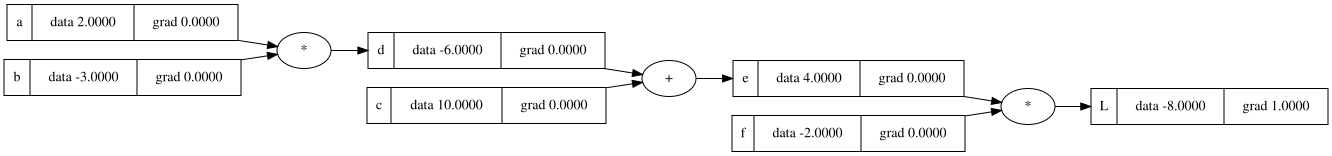

In [44]:
draw_dot(L)

- d = a*b 
- e = c + d
- L = e * f

- dL/dL = 1.0
- dL/de = f 
- dL/df = e 

- de/dc = 1.0
- de/dd = 1.0

- dd/da = b
- dd/db = a

- dL/dc = (dL/de) * (de/dc) = (f) * (1.0) = f
- dL/dd = (dL/de) * (de/dd) = (f) * (1.0) = f

- dL/da = (dL/dd) * (dd/da) = (f) * (b) = f * b
- dL/db = (dL/dd) * (dd/db) = (f) * (a) = f * a

In [45]:
L.grad = 1.0
e.grad = f.data
f.grad = e.data 
c.grad = f.data 
d.grad = f.data 
b.grad = f.data * a.data 
a.grad = f.data * b.data

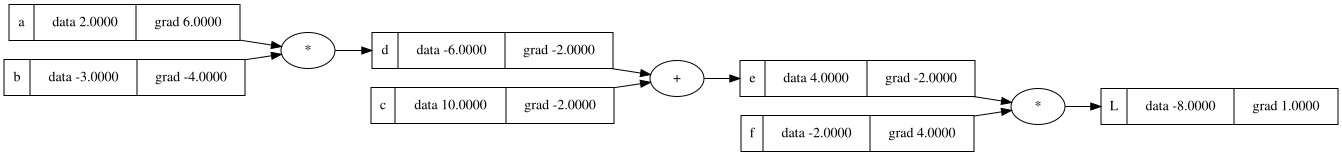

In [46]:
draw_dot(L)

In [47]:
def lol():
  h = 0.001
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  d = a * b
  d.label = 'd'
  e = d + c
  e.label = 'e'
  f = Value(-2.0, label='f')
  L = e * f
  L.label = 'L'
  
  L1 = L.data 
  
  a = Value(2.0, label='a')
  # a.data += h
  b = Value(-3.0, label='b')
  # b.data += h
  c = Value(10.0, label='c')
  # c.data += h
  d = a * b
  # d.data += h
  d.label = 'd'
  e = d + c
  # e.data += h
  e.label = 'e'
  f = Value(-2.0, label='f')
  # f.data += h
  L = e * f
  L.label = 'L'

  L2 = L.data
  
  print((L2 - L1) / h)

In [48]:
lol()

0.0


In [49]:
# move along grad (L value goes up)
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
d.data += 0.01 * d.grad
e.data += 0.01 * e.grad
f.data += 0.01 * f.grad

# forward pass
d = a * b
e = d + c
L = e * f
print(L.data)

-7.286496


example 2 - calculating grad manually

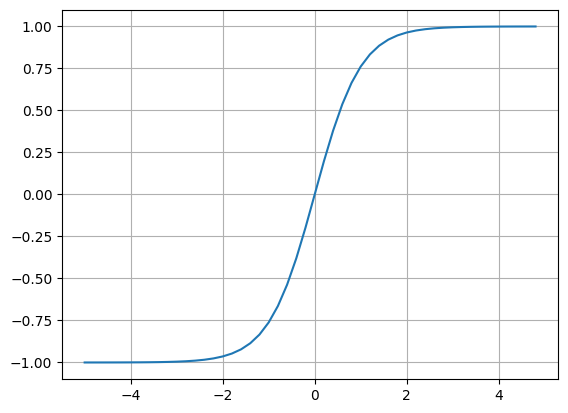

In [50]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()
plt.show()

In [93]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2 
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.881, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

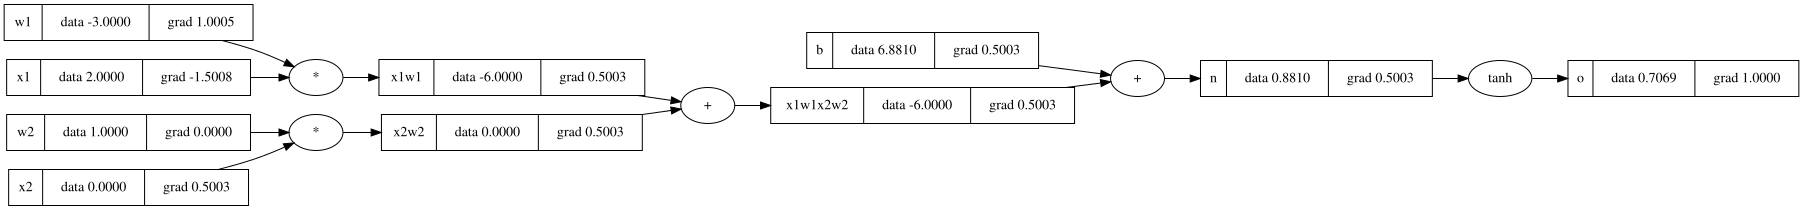

In [96]:
draw_dot(o)

In [ ]:
o.backward()

- o = tanh(n)
- do/do = 1.0
- do/dn = d(tanh(n))/dn = (1 - tanh(n)^2) * 1
- do/db = do/dn * dn/db = (1 - tanh(n)^2) * 1 * 1 = 1 - tanh(n)^2
- do/dx1w1x2w2 = do/dn * dn/dx1w1x2w2 = (1 - tanh(n)^2) * 1 * 1 = 1 - tanh(n)^2
- do/dx1w1 = do/dx1w1x2w2 * dx1w1x2w2/dx1w1 = (1 - tanh(n)^2) * 1 = 1 - tanh(n)^2
- do/dx2w2 = do/dx1w1x2w2 * dx1w1x2w2/dx2w2 = (1 - tanh(n)^2) * 1 = 1 - tanh(n)^2
- do/dx1 = do/dx1w1 * dx1w1/dx1 = (1 - tanh(n)^2) * w1 = (1 - tanh(n)^2)*w1
- do/dw1 = do/dx1w1 * dx1w1/dw1 = (1 - tanh(n)^2) * x1 = (1 - tanh(n)^2)*x1
- do/dx2 = do/dx2w2 * dx2w2/dx2 = (1 - tanh(n)^2) * w2 = (1 - tanh(n)^2)*w2
- do/dw2 = do/dx2w2 * dx2w2/dw2 = (1 - tanh(n)^2) * x2 = (1 - tanh(n)^2)*x2

In [63]:
# fill grad of 'o' manually calculating
# o = n.tanh()
o.grad = 1.0
n.grad = 1.0 - o.data ** 2
b.grad = n.grad * 1.0
x1w1x2w2.grad = n.grad * 1.0
x1w1.grad = x1w1x2w2.grad * 1.0
x2w2.grad = x1w1x2w2.grad * 1.0
x1.grad = x1w1.grad * w1.data
x2.grad = x2w2.grad * w2.data
w1.grad = x1w1.grad * x1.data
w2.grad = x2w2.grad * x2.data

In [89]:
# grad using backward propgation 
o.grad = 1.0 # base case initialization

In [77]:
o._backward()

In [79]:
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()

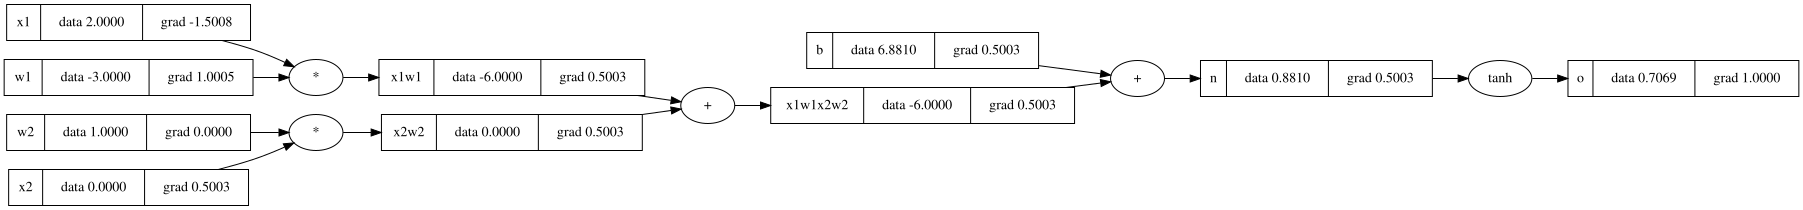

In [91]:
draw_dot(o)

Our computational graph is a directed acyclic graph(DAG). 

**goal: a particular order of grad calculation**
- compute gradient of parent nodes first.
- compute gradient of all children nodes wrt parent 

This flow is just opposite of what topological sorting would do.

![topo-sort](img/topo-sort.png)

ref: image taken from [here](https://medium.com/@konduruharish/topological-sort-in-typescript-and-c-6d5ecc4bad95)

In [85]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(o)
      

In [86]:
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881),
 Value(data=0.8810000000000002),
 Value(data=0.7069199383279539)]

In [ ]:
for node in reversed(topo): # make sure o.grad is initialized with 1.0
  node._backward()

**bug**

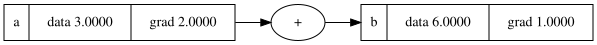

In [100]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

correct grad db/da is 2.0 not 1.0

In [102]:
a = Value(3.0, label='a')
a + 1

Value(data=4.0)

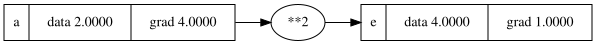

In [117]:
a = Value(2.0, label='a')
b = Value(4.0, label='b')

e = a ** 2 
e.label = 'e'
e.backward()
draw_dot(e)

Value(data=0.5)


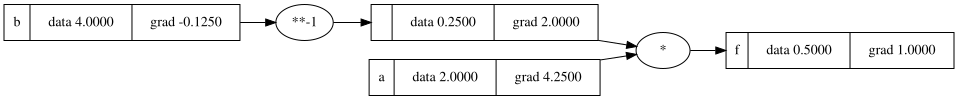

In [118]:
f = a / b
f.label = 'f'
f.backward()
print(f)
draw_dot(f)

Value(data=-2.0)


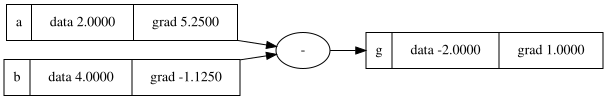

In [119]:
g = a - b
g.label = 'g'
g.backward()
print(g)
draw_dot(g)

pytorch example of our simple perceptron

In [121]:
import torch

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2 
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.881, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

In [122]:

x1 = torch.tensor(2.0, requires_grad=True) # default, torch puts grad false for leaf nodes
x2 = torch.tensor(0.0, requires_grad=True)

# weights w1, w2
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)

b = torch.tensor(6.881, requires_grad=True)

x1w1 = x1 * w1
x2w2 = x2 * w2

n = x1w1 + x2w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()

print(x1.grad)
print(x2.grad)
print(w1.grad)
print(w2.grad)

0.7069199681282043
tensor(-1.5008)
tensor(0.5003)
tensor(1.0005)
tensor(0.)


In [123]:
import random

In [204]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))
    
  def __call__(self, x):
    # w * x + b
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    params = []
    for n in self.neurons:
      params.extend(n.parameters())
    return params

class MLP:
  def __init__(self, nin, nouts):
    self.layers = []
    last_size = nin
    for nout in nouts:
      layer = Layer(last_size, nout)
      self.layers.append(layer)
      last_size = nout

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    params = []
    for layer in self.layers:
      params.extend(layer.parameters())
    return params

In [205]:
n = Neuron(3)
# print(n.w)
x = [2.0, 3.0, -1.0]
o = n(x) # n.__call__(x)
print(o)

Value(data=-0.9756018360486438)


In [206]:
l = Layer(3, 4)
for i in l.neurons: # i.neurons is list of 4 Neuron(3) object, 4 is no of neurons in next layer
  print(i.w, i.b) # each 4 neurons connects to 3 inputs(w) and 1 bias to prev layer
  act = i(x) # compute act for ith neuron
  print(act)

[Value(data=0.49085133773146117), Value(data=-0.7365779184836447), Value(data=0.925611713827897)] Value(data=-0.7183471536794157)
Value(data=-0.9936164416258545)
[Value(data=0.8247656138905743), Value(data=0.6995197703303839), Value(data=-0.2105652642928355)] Value(data=-0.9221118294803452)
Value(data=0.9954024979877387)
[Value(data=0.9335185122534022), Value(data=-0.20153370966956596), Value(data=-0.2725553795090432)] Value(data=0.856541392971323)
Value(data=0.9833983571308728)
[Value(data=0.555870179706655), Value(data=-0.5026102648874915), Value(data=-0.5851817545332652)] Value(data=-0.6776195004298222)
Value(data=-0.45304748793111643)


In [207]:
o = l(x)
print(o)

[Value(data=-0.9936164416258545), Value(data=0.9954024979877387), Value(data=0.9833983571308728), Value(data=-0.45304748793111643)]


Use **MLP**

![mlp](img/mlp.jpg)

In [259]:
x = [2.0, 3.0, -1.0] # for 1 example
n = MLP(3, [4, 4, 1])
# o = n(x)
# print(o)

In [260]:
len(n.parameters())

41

Use **MLP** for sample datasets

In [ ]:
# xs = [] # 10 x 3 (10 rows, 3 columns)
# ys = [] # 10 x 1 binary
# for _ in range(10):
#   xs.append([random.uniform(-1, 1) for _ in range(3)])
#   ys.append(random.choice([-1, 1])) # -1 or 1


In [263]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [262]:
ys

[-1, -1, -1, 1, -1, 1, -1, 1, -1, 1]

How to tune weights so ypred is close to ys? 
- use loss function and minimize it

Note loss decreased by tiny amount

Combine forward pass, loss compute, backward pass with n of iterations

In [266]:
def train(xs, ys, n_iter=100, lr=0.01):
  for k in range(n_iter):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for yout, ygt in zip(ypred, ys)), Value(0.0))

    # zero grad (if you don't do, prev grad just keeps accumulating due to +=)
    for p in n.parameters():
      p.grad = 0.0

    # backward pass
    loss.backward()

    # update parameters
    for p in n.parameters():
      p.data += -lr * p.grad

    if (k+1)%5 == 0:
      print(f"iter:{k+1}, loss:{loss.data}")

In [267]:
train(xs, ys, n_iter=50, lr=0.001)

iter:5, loss:0.007944694761007768
iter:10, loss:0.007923409597716806
iter:15, loss:0.007902236214559303
iter:20, loss:0.007881178651169858
iter:25, loss:0.007860224271195109
iter:30, loss:0.007839380753072368
iter:35, loss:0.00781864541546538
iter:40, loss:0.007798017604010944
iter:45, loss:0.00777750021976444
iter:50, loss:0.007757089340047866


In [270]:
ypred = [n(x) for x in xs]

In [273]:
for yp, yg in zip(ypred, ys):
  print(round(yp.data, 2), yg)

0.94 1.0
-1.0 -1.0
-0.99 -1.0
0.94 1.0
